In [ ]:
"""
find_6pct_pointing_step8.py
─────────────────────────────────────────────────────────────────────────────
Same idea as find_6pct_pointing.py, but targets the REAL final pixel-loss
number: Step 8's combined_pointings_YYYY-MM-DD.csv, column
"total_pixel_loss_fraction" — not Step 5's early, uncorrected v1 estimate.

Step 8 only writes rows for pointings that contain at least one streak
brighter than MAG_LIMIT (2.0 mag) — i.e. pointings with zero "bright"
streaks never appear in combined_pointings_*.csv at all. That's expected;
this finder only searches within pointings Step 8 actually processed.

Also reports n_bright_streaks / n_normal_streaks / n_ccds_dead so you can
see WHY a given pointing's loss is high (whole dead CCDs vs. normal masked
streaks) before picking one for the pixel-level overlap analysis.

USAGE
─────
    python find_6pct_pointing_step8.py
"""

import os
import glob
import pandas as pd

# ═════════════════════════════════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════════════════════════════════

STEP8_DIR   = "step5_combined_loss_output_rad"   # matches step8's main() output_dir
TARGET_FRAC = 0.50
TOLERANCE   = 0.005
TOP_N       = 15

LOSS_COL = "total_pixel_loss_fraction"


def main():
    paths = sorted(glob.glob(os.path.join(STEP8_DIR, "combined_pointings_*.csv")))
    if not paths:
        raise FileNotFoundError(
            f"No combined_pointings_*.csv found in {STEP8_DIR} — "
            f"check STEP8_DIR matches step8_ccd_pixel.py's output_dir."
        )

    print(f"[INFO] Scanning {len(paths)} day file(s) in {STEP8_DIR} "
          f"for pointings near {TARGET_FRAC*100:.1f}% pixel loss "
          f"(column: {LOSS_COL}) ...\n")

    frames = []
    for p in paths:
        date_str = (os.path.basename(p)
                    .replace("combined_pointings_", "")
                    .replace(".csv", ""))
        try:
            df = pd.read_csv(p)
        except pd.errors.EmptyDataError:
            continue
        except Exception as e:
            print(f"  [WARN] could not read {p}: {e}")
            continue
        if df.empty or LOSS_COL not in df.columns:
            continue
        df = df.copy()
        df["date"] = date_str
        frames.append(df)

    if not frames:
        raise RuntimeError("No usable combined_pointings files found.")

    all_pts = pd.concat(frames, ignore_index=True)
    print(f"[INFO] Loaded {len(all_pts):,} pointings total across all days "
          f"(only pointings with >=1 streak brighter than MAG_LIMIT=2.0 "
          f"appear here — that's a Step 8 design choice, not a filter "
          f"applied by this script)\n")

    all_pts["dist_from_target"] = (all_pts[LOSS_COL] - TARGET_FRAC).abs()
    all_pts_sorted = all_pts.sort_values("dist_from_target")

    # ── Best single match ────────────────────────────────────────────────
    best = all_pts_sorted.iloc[0]
    print("=" * 70)
    print("BEST MATCH (Step 8 — real final combined pixel loss)")
    print("=" * 70)
    for col in ["date", "pointing_id", "pointing_ra", "pointing_dec",
                "pointing_filter", "pointing_exptime", "pointing_night",
                "rot_sky_pos",
                "n_bright_streaks", "n_normal_streaks", "n_ccds_dead",
                "dead_pixel_loss", "normal_pixel_loss_clipped",
                "total_pixel_loss", LOSS_COL]:
        if col in best.index:
            print(f"  {col:32s}: {best[col]}")
    print()

    # ── Top-N closest matches ───────────────────────────────────────────
    print("=" * 70)
    print(f"TOP {TOP_N} CLOSEST MATCHES")
    print("=" * 70)
    show_cols = ["date", "pointing_id", "pointing_filter",
                 "n_bright_streaks", "n_normal_streaks", "n_ccds_dead",
                 LOSS_COL, "dist_from_target"]
    show_cols = [c for c in show_cols if c in all_pts_sorted.columns]
    print(all_pts_sorted[show_cols].head(TOP_N).to_string(index=False))
    print()

    # ── Candidates with ZERO dead CCDs (purely "normal" streak loss) ────
    # These are more interesting for a pixel-overlap demo: no whole-CCD
    # wipeouts, so the loss is entirely from masked streak polygons —
    # exactly the regime where overlapping electrons can change the mask
    # width story.
    no_dead = all_pts[all_pts["n_ccds_dead"] == 0].copy()
    if len(no_dead) > 0:
        no_dead["dist_from_target"] = (no_dead[LOSS_COL] - TARGET_FRAC).abs()
        no_dead_sorted = no_dead.sort_values("dist_from_target")
        print("=" * 70)
        print(f"TOP {min(TOP_N, len(no_dead))} CLOSEST MATCHES WITH ZERO DEAD CCDs "
              f"(pure normal-streak loss — best for pixel-overlap demo)")
        print("=" * 70)
        print(no_dead_sorted[show_cols].head(TOP_N).to_string(index=False))
    else:
        print("[INFO] No pointings with zero dead CCDs found in this scan.")

    # ── All candidates within tolerance window ──────────────────────────
    window = all_pts[all_pts["dist_from_target"] <= TOLERANCE]
    print("\n" + "=" * 70)
    print(f"ALL CANDIDATES WITHIN ±{TOLERANCE*100:.1f}% OF TARGET "
          f"({len(window)} found)")
    print("=" * 70)
    if len(window) > 0:
        print(window.sort_values(LOSS_COL)[show_cols].to_string(index=False))
    else:
        print("  (none — widen TOLERANCE)")

    out_path = "candidates_6pct_pixelloss_step8.csv"
    all_pts_sorted.head(200).to_csv(out_path, index=False)
    print(f"\n[SAVED] top 200 closest matches -> {out_path}")


if __name__ == "__main__":
    main()

[INFO] Scanning 516 day file(s) in step5_combined_loss_output_rad for pointings near 50.0% pixel loss (column: total_pixel_loss_fraction) ...

[INFO] Loaded 6,773 pointings total across all days (only pointings with >=1 streak brighter than MAG_LIMIT=2.0 appear here — that's a Step 8 design choice, not a filter applied by this script)

BEST MATCH (Step 8 — real final combined pixel loss)
  date                            : 2032-05-20
  pointing_id                     : 1071533
  pointing_ra                     : 131.6871
  pointing_dec                    : -21.28356
  pointing_filter                 : y
  pointing_exptime                : 30.0
  pointing_night                  : 2165
  rot_sky_pos                     : 54.2619
  n_bright_streaks                : 51
  n_normal_streaks                : 402
  n_ccds_dead                     : 51
  dead_pixel_loss                 : 855638016
  normal_pixel_loss_clipped       : 744378664.3
  total_pixel_loss                : 1600016680.3
  

In [9]:
"""
find_6pct_pointing_step8.py
─────────────────────────────────────────────────────────────────────────────
Same idea as find_6pct_pointing.py, but targets the REAL final pixel-loss
number: Step 8's combined_pointings_YYYY-MM-DD.csv, column
"total_pixel_loss_fraction" — not Step 5's early, uncorrected v1 estimate.

Step 8 only writes rows for pointings that contain at least one streak
brighter than MAG_LIMIT (2.0 mag) — i.e. pointings with zero "bright"
streaks never appear in combined_pointings_*.csv at all. That's expected;
this finder only searches within pointings Step 8 actually processed.

Also reports n_bright_streaks / n_normal_streaks / n_ccds_dead so you can
see WHY a given pointing's loss is high (whole dead CCDs vs. normal masked
streaks) before picking one for the pixel-level overlap analysis.

WINDOW
──────
Restricted to the fixed 365-day window, 2026-06-29 to 2027-06-28. Only
combined_pointings_*.csv files whose date falls in that window are read
— filtering happens BEFORE any CSV is opened, same convention used
throughout the rest of this pipeline.

USAGE
─────
    python find_6pct_pointing_step8.py
"""

import os
import glob
import re
import pandas as pd

# ═════════════════════════════════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════════════════════════════════

STEP8_DIR   = "step5_combined_loss_output_rad"   # matches step8's main() output_dir
STEP5_DIR   = "step5_output_v2_rad"               # step5's own per-pointing file
                                                    # (has the n_saturated/n_unsaturated
                                                    # breakdown that step8's output lacks)
TARGET_FRAC = 0.51
TOLERANCE   = 0.005
TOP_N       = 15

LOSS_COL = "total_pixel_loss_fraction"

# Fixed 365-day window (same convention used throughout this pipeline)
FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")


def get_date_from_filename(path):
    m = DATE_RE.search(os.path.basename(path))
    return m.group(1) if m else None


def _filter_to_window(paths):
    kept = []
    for p in paths:
        date_str = get_date_from_filename(p)
        if date_str is None:
            continue
        try:
            d = pd.to_datetime(date_str)
        except Exception:
            continue
        if FIRST_DATE <= d < CUTOFF_DATE:
            kept.append(p)
    print(f"[INFO] Window filter: keeping {len(kept)} of {len(paths)} files "
          f"({FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()})")
    return kept


def load_step5_saturation_breakdown(date_str):
    """Step 8's own output has no saturated/unsaturated split (only
    undifferentiated n_normal_streaks) -- that breakdown only exists in
    Step 5's own per-pointing file. Returns a DataFrame with just
    pointing_id, n_saturated, n_unsaturated, n_faint for this date, or
    an empty frame (with the right columns) if the file is missing."""
    cols = ["pointing_id", "n_saturated", "n_unsaturated", "n_faint"]
    path = os.path.join(STEP5_DIR, f"step5_pointings_{date_str}.csv")
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        return pd.DataFrame(columns=cols)
    try:
        df = pd.read_csv(path, usecols=lambda c: c in cols)
    except (pd.errors.EmptyDataError, ValueError):
        return pd.DataFrame(columns=cols)
    for c in cols:
        if c not in df.columns:
            df[c] = pd.NA
    return df[cols]


def main():
    all_paths = sorted(glob.glob(os.path.join(STEP8_DIR, "combined_pointings_*.csv")))
    if not all_paths:
        raise FileNotFoundError(
            f"No combined_pointings_*.csv found in {STEP8_DIR} — "
            f"check STEP8_DIR matches step8_ccd_pixel.py's output_dir."
        )

    paths = _filter_to_window(all_paths)
    if not paths:
        raise FileNotFoundError(
            f"No combined_pointings_*.csv in {STEP8_DIR} fall inside the "
            f"{FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()} window."
        )

    print(f"[INFO] Scanning {len(paths)} day file(s) in {STEP8_DIR} "
          f"for pointings near {TARGET_FRAC*100:.1f}% pixel loss "
          f"(column: {LOSS_COL}) ...\n")

    frames = []
    for p in paths:
        date_str = get_date_from_filename(p)
        try:
            df = pd.read_csv(p)
        except pd.errors.EmptyDataError:
            continue
        except Exception as e:
            print(f"  [WARN] could not read {p}: {e}")
            continue
        if df.empty or LOSS_COL not in df.columns:
            continue
        df = df.copy()
        df["date"] = date_str

        # Join in Step 5's saturated/unsaturated/faint breakdown, matched
        # on pointing_id -- see load_step5_saturation_breakdown() docstring
        # for why this can't just be read from step8's own output.
        sat_breakdown = load_step5_saturation_breakdown(date_str)
        df = df.merge(sat_breakdown, on="pointing_id", how="left")

        frames.append(df)

    if not frames:
        raise RuntimeError("No usable combined_pointings files found.")

    all_pts = pd.concat(frames, ignore_index=True)
    print(f"[INFO] Loaded {len(all_pts):,} pointings total across all days "
          f"(only pointings with >=1 streak brighter than MAG_LIMIT=2.0 "
          f"appear here — that's a Step 8 design choice, not a filter "
          f"applied by this script)\n")

    all_pts["dist_from_target"] = (all_pts[LOSS_COL] - TARGET_FRAC).abs()
    all_pts_sorted = all_pts.sort_values("dist_from_target")

    # ── Best single match ────────────────────────────────────────────────
    best = all_pts_sorted.iloc[0]
    print("=" * 70)
    print("BEST MATCH (Step 8 — real final combined pixel loss)")
    print("=" * 70)
    for col in ["date", "pointing_id", "pointing_ra", "pointing_dec",
                "pointing_filter", "pointing_exptime", "pointing_night",
                "rot_sky_pos",
                "n_bright_streaks", "n_normal_streaks", "n_ccds_dead",
                "n_saturated", "n_unsaturated", "n_faint",
                "dead_pixel_loss", "normal_pixel_loss_clipped",
                "total_pixel_loss", LOSS_COL]:
        if col in best.index:
            print(f"  {col:32s}: {best[col]}")
    print()

    # ── Top-N closest matches ───────────────────────────────────────────
    print("=" * 70)
    print(f"TOP {TOP_N} CLOSEST MATCHES")
    print("=" * 70)
    show_cols = ["date", "pointing_id", "pointing_filter",
                 "n_bright_streaks", "n_normal_streaks", "n_ccds_dead",
                 "n_saturated", "n_unsaturated",
                 LOSS_COL, "dist_from_target"]
    show_cols = [c for c in show_cols if c in all_pts_sorted.columns]
    print(all_pts_sorted[show_cols].head(TOP_N).to_string(index=False))
    print()

    # ── Candidates with ZERO dead CCDs (purely "normal" streak loss) ────
    # These are more interesting for a pixel-overlap demo: no whole-CCD
    # wipeouts, so the loss is entirely from masked streak polygons —
    # exactly the regime where overlapping electrons can change the mask
    # width story.
    no_dead = all_pts[all_pts["n_ccds_dead"] == 0].copy()
    if len(no_dead) > 0:
        no_dead["dist_from_target"] = (no_dead[LOSS_COL] - TARGET_FRAC).abs()
        no_dead_sorted = no_dead.sort_values("dist_from_target")
        print("=" * 70)
        print(f"TOP {min(TOP_N, len(no_dead))} CLOSEST MATCHES WITH ZERO DEAD CCDs "
              f"(pure normal-streak loss — best for pixel-overlap demo)")
        print("=" * 70)
        print(no_dead_sorted[show_cols].head(TOP_N).to_string(index=False))
    else:
        print("[INFO] No pointings with zero dead CCDs found in this scan.")

    # ── All candidates within tolerance window ──────────────────────────
    window = all_pts[all_pts["dist_from_target"] <= TOLERANCE]
    print("\n" + "=" * 70)
    print(f"ALL CANDIDATES WITHIN ±{TOLERANCE*100:.1f}% OF TARGET "
          f"({len(window)} found)")
    print("=" * 70)
    if len(window) > 0:
        print(window.sort_values(LOSS_COL)[show_cols].to_string(index=False))
    else:
        print("  (none — widen TOLERANCE)")

    out_path = "candidates_6pct_pixelloss_step8.csv"
    all_pts_sorted.head(200).to_csv(out_path, index=False)
    print(f"\n[SAVED] top 200 closest matches -> {out_path}")


if __name__ == "__main__":
    main()

[INFO] Window filter: keeping 55 of 516 files (2026-06-29 to 2027-06-28)
[INFO] Scanning 55 day file(s) in step5_combined_loss_output_rad for pointings near 51.0% pixel loss (column: total_pixel_loss_fraction) ...

[INFO] Loaded 732 pointings total across all days (only pointings with >=1 streak brighter than MAG_LIMIT=2.0 appear here — that's a Step 8 design choice, not a filter applied by this script)

BEST MATCH (Step 8 — real final combined pixel loss)
  date                            : 2026-07-30
  pointing_id                     : 23307
  pointing_ra                     : 39.05359
  pointing_dec                    : -30.53711
  pointing_filter                 : y
  pointing_exptime                : 30.0
  pointing_night                  : 44
  rot_sky_pos                     : 132.8415
  n_bright_streaks                : 283
  n_normal_streaks                : 276
  n_ccds_dead                     : 96
  n_saturated                     : 469
  n_unsaturated                   : 2

In [ ]:
#!/usr/bin/env python3
"""
plot_pointing_naive_vs_combined.py
─────────────────────────────────────────────────────────────────────────────
2-panel diagnostic plot for ONE pointing on ONE date: exactly the first two
panels of step9_updated_px_loss.py's plot_pointing(), extracted as a
standalone script -- no mask-polygon panel, no overlap-area computation at
all.

LEFT panel  (NAIVE)    -- each normal streak's status BEFORE any electron
                          summing: just that streak's own individual_status
                          (unsaturated / saturated), judged completely
                          alone. This is "what streak is it" -- the plain
                          per-streak classification with no knowledge of
                          any other streak.
RIGHT panel (COMBINED) -- status AFTER electron summing: at every pixel a
                          streak's rasterized centerline passes through,
                          this sums that pixel's electrons across every
                          streak that also passes through it, and
                          reclassifies from the SUMMED total. A streak can
                          get upgraded here (e.g. unsaturated -> saturated)
                          if enough other streaks cross the same pixels.
                          This does NOT draw or compute mask-polygon
                          overlap area at all -- it is centerline-only,
                          exactly matching step9's own "COMBINED" panel.

Both panels are pixel scatter plots (not lines) of the streaks'
RASTERIZED centerline pixels, colored by status -- identical rendering to
step9_updated_px_loss.py's own plot_pointing(), just without the third
panel and without ever calling build_mask_polygons/find_polygon_overlaps/
rebuild_polygons_precise (those are skipped entirely, since this plot
doesn't need them).

USAGE
─────
    python3 plot_pointing_naive_vs_combined.py --date 2026-07-31 --pointing-id 23838

    # override paths / opsim DB if not using the defaults:
    python3 plot_pointing_naive_vs_combined.py --date 2026-07-31 --pointing-id 23838 \
        --step2-dir step2_output --step4b-dir step4b_output_rad \
        --step6-dir step6_output_perband_rad --opsim-db baseline_v5.3.0_10yrs.db \
        --out-dir plots_naive_vs_combined
"""

import argparse
import os

import matplotlib
# NOTE: no matplotlib.use("Agg") here -- that forces a non-interactive,
# save-only backend meant for headless/cluster runs, which would silently
# write the PNG but never actually display anything inline in a notebook
# cell. Leaving the backend unset lets Jupyter's own inline backend take
# over automatically.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch, Circle
from matplotlib.lines import Line2D

# Reuses step9's own physics/constants/loaders directly -- no
# reimplementation, guaranteed consistent with every other result in the
# paper. step9_updated_px_loss.py must be importable (same directory).
import step9_updated_px_loss as s9


def plot_naive_vs_combined(bright_streaks, normal_streaks, pixel_combined_e,
                            pixel_contributors, meta, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

    for ax in axes:
        for ccd_id, (x0, x1, y0, y1) in s9.CCD_BBOX_PX.items():
            is_dead = any(ccd_id in b["hit_ccds"] for b in bright_streaks)
            ax.add_patch(Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                facecolor="black" if is_dead else "#dbe4f0",
                alpha=0.35 if is_dead else 0.6,
                edgecolor="#888888", linewidth=0.3,
            ))
        ax.add_patch(Circle(
            (0, 0), s9.FOV_RADIUS_PX,
            facecolor="none", edgecolor="black", linewidth=1.2, zorder=5,
        ))
        # Layer 1 (bottom): red ultrabright streaks, drawn first so
        # everything else in the requested draw order paints on top of it.
        for b in bright_streaks:
            ax.plot(b["wp_x"], b["wp_y"], color=s9.STATUS_COLORS["ultrabright"],
                     linewidth=1.5, zorder=6, solid_capstyle="round")

    # Axes limits MUST be set before computing the data-to-points
    # conversion below -- that conversion depends on the axes' final
    # displayed size and data range, both of which are only correct once
    # xlim/ylim are fixed.
    all_x0 = min(min(b[0] for b in s9.CCD_BBOX_PX.values()), -s9.FOV_RADIUS_PX)
    all_x1 = max(max(b[1] for b in s9.CCD_BBOX_PX.values()), s9.FOV_RADIUS_PX)
    all_y0 = min(min(b[2] for b in s9.CCD_BBOX_PX.values()), -s9.FOV_RADIUS_PX)
    all_y1 = max(max(b[3] for b in s9.CCD_BBOX_PX.values()), s9.FOV_RADIUS_PX)
    pad = 0.03 * (all_x1 - all_x0)
    for ax in axes:
        ax.set_xlim(all_x0 - pad, all_x1 + pad)
        ax.set_ylim(all_y0 - pad, all_y1 + pad)
        ax.set_aspect("equal")

    def linewidth_for_data_pixels(ax, data_px):
        """Converts a width given in DATA coordinates (camera-frame px,
        e.g. the real 100px/500px mask widths) into the matplotlib
        `linewidth` value (points) that will actually render at that
        width on screen, using this axes' real, final data-to-display
        scale -- NOT a fixed/guessed constant, since that scale depends
        on the actual figure size and axis limits. Without this, every
        streak was rendered at the same fixed, arbitrary marker size
        regardless of whether it was a 100px-wide unsaturated mask or a
        500px-wide saturated one -- five times too wide or too narrow
        relative to what the real pixel-loss mask actually covers."""
        # 1 point = 1/72 inch. Figure out how many data-px correspond to
        # 1 inch on THIS axes, via its bounding box in display (pixel)
        # space vs its data limits.
        bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
        width_inches = bbox.width
        xlim = ax.get_xlim()
        data_px_per_inch = (xlim[1] - xlim[0]) / width_inches
        data_px_per_point = data_px_per_inch / 72.0
        return data_px / data_px_per_point

    def draw_streaks(ax, streaks_with_style, zorder_base=7):
        """streaks_with_style: list of (streak, color, mask_width_px),
        drawn as a single ax.plot per streak with linewidth scaled to
        mask_width_px via linewidth_for_data_pixels."""
        for s, color, mask_width_px in streaks_with_style:
            wp_x, wp_y = s.get("wp_x"), s.get("wp_y")
            if wp_x is None or len(wp_x) < 2 or mask_width_px <= 0:
                continue
            lw = linewidth_for_data_pixels(ax, mask_width_px)
            ax.plot(wp_x, wp_y, color=color, linewidth=lw,
                     solid_capstyle="round", zorder=zorder_base,
                     rasterized=True)

    # ── LEFT (NAIVE): draw order per your requested layering -- orange
    # (saturated) first, then blue (unsaturated) on top. Width reflects
    # each streak's OWN individual mask width (100px / 500px). ─────────
    naive_sat_streaks = [
        (s, s9.STATUS_COLORS["saturated"], s9.MASK_WIDTH_PX["saturated"])
        for s in normal_streaks if s["individual_status"] == "saturated"
    ]
    naive_unsat_streaks = [
        (s, s9.STATUS_COLORS["unsaturated"], s9.MASK_WIDTH_PX["unsaturated"])
        for s in normal_streaks if s["individual_status"] == "unsaturated"
    ]
    draw_streaks(axes[0], naive_sat_streaks, zorder_base=7)
    draw_streaks(axes[0], naive_unsat_streaks, zorder_base=8)
    axes[0].set_title("NAIVE — each streak judged alone\n(before electron summing)")
    axes[0].set_xlabel("camera-frame x (px)")
    axes[0].set_ylabel("camera-frame y (px)")

    # ── RIGHT (COMBINED): same order, then upgraded streaks (magenta,
    # widened to their NEW/worse mask width) drawn last, on top. ───────
    combined_sat_streaks, combined_unsat_streaks, combined_upgraded_streaks = [], [], []
    for s in normal_streaks:
        cs = s.get("combined_status", s["individual_status"])
        if cs == "faint":
            continue
        w = s9.MASK_WIDTH_PX.get(cs, 0)
        if s.get("upgraded"):
            combined_upgraded_streaks.append((s, "black", w))
        elif cs == "saturated":
            combined_sat_streaks.append((s, s9.STATUS_COLORS["saturated"], w))
        else:
            combined_unsat_streaks.append((s, s9.STATUS_COLORS["unsaturated"], w))

    draw_streaks(axes[1], combined_sat_streaks, zorder_base=7)
    draw_streaks(axes[1], combined_unsat_streaks, zorder_base=8)
    draw_streaks(axes[1], combined_upgraded_streaks, zorder_base=20)
    if combined_upgraded_streaks:
        axes[1].plot([], [], color="black", linewidth=3,
                     label=f"upgraded ({len(combined_upgraded_streaks)} streaks)")
        axes[1].legend(loc="upper right", fontsize=9, framealpha=0.9)

    axes[1].set_title("COMBINED — overlapping streaks' electrons summed")
    axes[1].set_xlabel("camera-frame x (px)")

    handles = [Patch(color=s9.STATUS_COLORS[s], label=s) for s in s9.PLOT_STATUSES[:-1]]
    handles.append(Line2D([0], [0], color=s9.STATUS_COLORS["ultrabright"], linewidth=1.5,
                          label="ultrabright streak (ab_mag < 2.0)"))
    handles.append(Patch(color="black", alpha=0.35, label="dead CCD (bright streak)"))
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False)

    n_up_centerline = sum(1 for s in normal_streaks if s.get("upgraded"))
    fig.suptitle(
        f"Pointing_id={meta['pointing_id']}  date={meta['date']} | "
        f"filter={meta['pointing_filter']}  rot_sky_pos={meta['rot_sky_pos']:.1f}° | "
        f"bright={meta['n_bright_streaks']}  normal={meta['n_normal_streaks']}  ",
        fontsize=11,
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.91])
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close(fig)


def run(date, pointing_id, step2_dir="step2_output", step4b_dir="step4b_output_rad",
        step6_dir="step6_output_perband_rad", opsim_db="baseline_v5.3.0_10yrs.db",
        rot_sky_pos_override=None, out_dir="plots_naive_vs_combined"):
    """Plain callable version -- use this directly in a notebook cell,
    e.g. run("2026-07-31", 23838). Does the actual work; main() below
    is just a thin CLI wrapper around this for script/terminal use."""
    os.makedirs(out_dir, exist_ok=True)

    print(f"[INFO] Loading {date} …")
    df_date = s9.load_date_frames(date, step2_dir, step4b_dir)
    sb_lookup_date = s9.load_step6_for_date(date, step6_dir)
    rot_sky_pos = s9.get_rot_sky_pos(pointing_id, opsim_db, rot_sky_pos_override)

    print(f"[INFO] Building pointing_id={pointing_id} …")
    bright_streaks, normal_streaks, meta = s9.build_pointing_from_frames(
        df_date, pointing_id, sb_lookup_date, rot_sky_pos, date_str=date
    )
    print(f"  {meta['n_bright_streaks']} bright, {meta['n_normal_streaks']} normal streaks")

    # Only the centerline/electron-summing stage -- deliberately stops
    # here, never calls build_mask_polygons/find_polygon_overlaps/
    # rebuild_polygons_precise, since this plot has no mask-polygon panel.
    pixel_combined_e, pixel_contributors = s9.accumulate_pixels(normal_streaks)
    normal_streaks = s9.evaluate_upgrades(normal_streaks, pixel_combined_e)

    n_up = sum(1 for s in normal_streaks if s.get("upgraded"))
    print(f"  {n_up} streak(s) upgraded by electron summing (centerline-only)")

    out_path = os.path.join(out_dir, f"naive_vs_combined_{date}_pt{pointing_id}.png")
    plot_naive_vs_combined(bright_streaks, normal_streaks, pixel_combined_e,
                            pixel_contributors, meta, out_path)
    print(f"[SAVED] {out_path}")
    return out_path


def main():
    ap = argparse.ArgumentParser(description=__doc__,
                                  formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--date", required=True, help="YYYY-MM-DD")
    ap.add_argument("--pointing-id", type=int, required=True)
    ap.add_argument("--step2-dir", default="step2_output")
    ap.add_argument("--step4b-dir", default="step4b_output_rad")
    ap.add_argument("--step6-dir", default="step6_output_perband_rad")
    ap.add_argument("--opsim-db", default="baseline_v5.3.0_10yrs.db")
    ap.add_argument("--rot-sky-pos", type=float, default=None,
                     help="Override rotSkyPos instead of looking it up in --opsim-db.")
    ap.add_argument("--out-dir", default="plots_naive_vs_combined")
    args = ap.parse_args()

    run(args.date, args.pointing_id, args.step2_dir, args.step4b_dir,
        args.step6_dir, args.opsim_db, args.rot_sky_pos, args.out_dir)


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] --date DATE --pointing-id POINTING_ID
                             [--step2-dir STEP2_DIR] [--step4b-dir STEP4B_DIR]
                             [--step6-dir STEP6_DIR] [--opsim-db OPSIM_DB]
                             [--rot-sky-pos ROT_SKY_POS] [--out-dir OUT_DIR]
ipykernel_launcher.py: error: the following arguments are required: --date, --pointing-id


SystemExit: 2

/u/njangid2/.conda/envs/lumos-env/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [4]:
run("2026-07-31", 23838)

[INFO] Loading 2026-07-31 …
[INFO] Building pointing_id=23838 …
  250 bright, 257 normal streaks
  21 streak(s) upgraded by electron summing (centerline-only)
[SAVED] plots_naive_vs_combined/naive_vs_combined_2026-07-31_pt23838.png


'plots_naive_vs_combined/naive_vs_combined_2026-07-31_pt23838.png'

[INFO] rot_sky_pos loaded from opsim DB = 71.826
[SAVED] pixel_level_2026-10-10_pt45679_zoomed.png


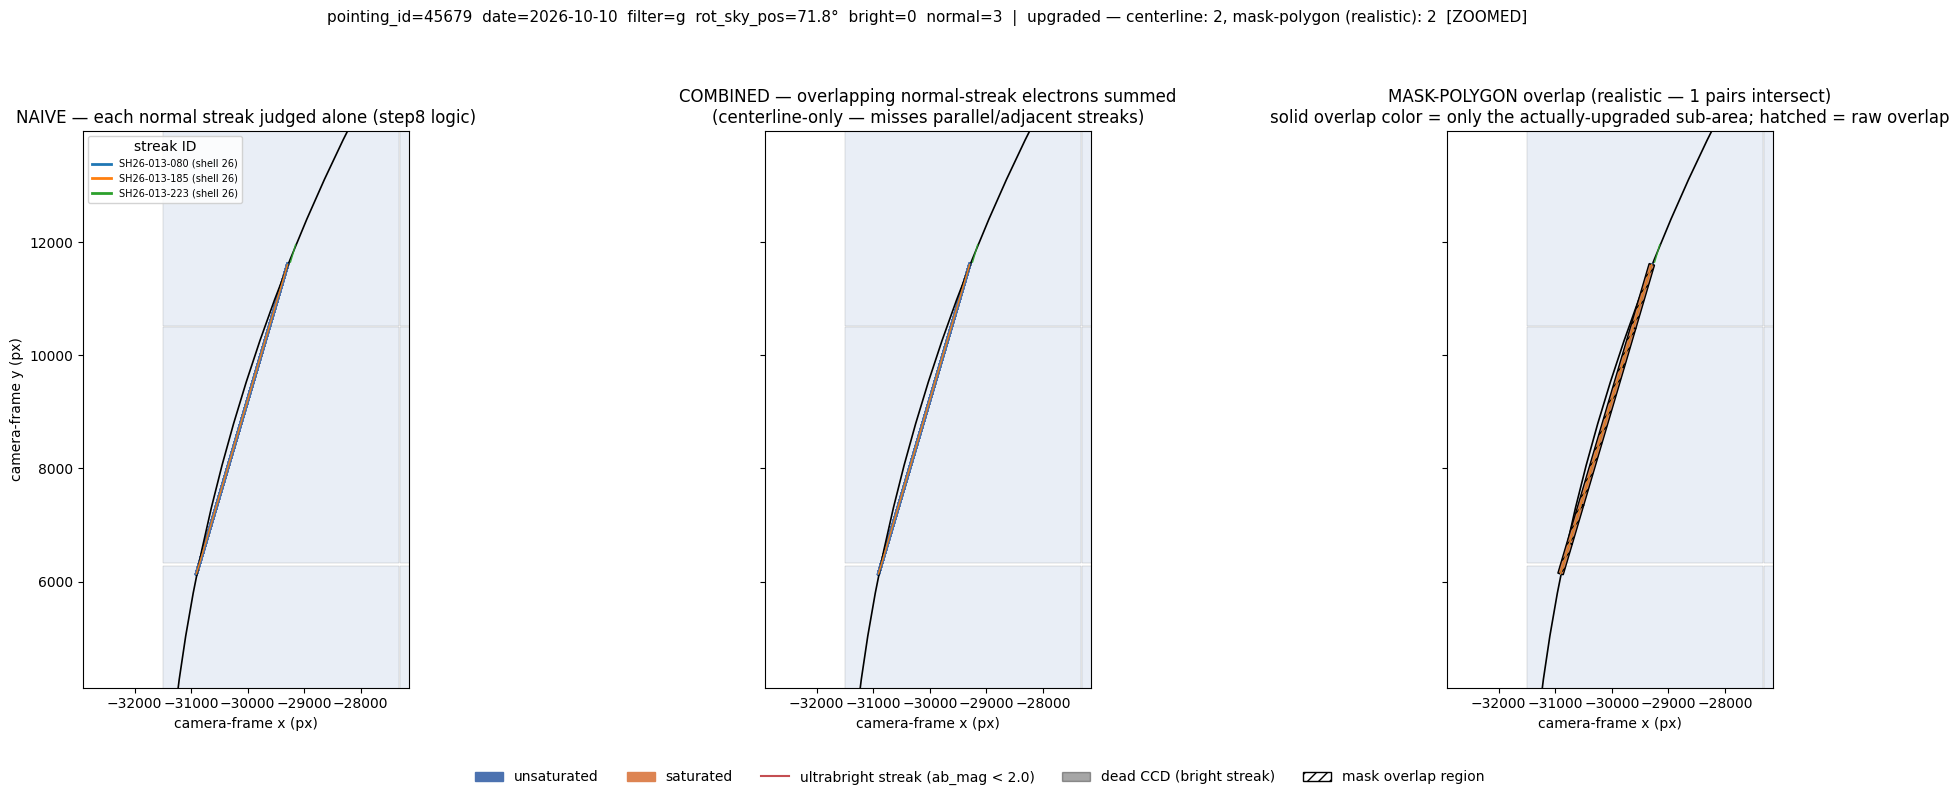

In [10]:
# ── Paste this in a new cell, after the cell(s) that already define
# load_pointing, accumulate_pixels, evaluate_upgrades, build_mask_polygons,
# find_polygon_overlaps, rebuild_polygons_precise, STATUS_ORDER,
# STATUS_COLORS, PLOT_STATUSES, CMAP, CCD_BBOX_PX, FOV_RADIUS_PX,
# classify_from_electrons, and your CONFIG block (DATE, POINTING_ID, etc).

from matplotlib.lines import Line2D


def compute_zoom_bounds(bright_streaks, normal_streaks, pad_frac=0.15, min_pad_px=2000):
    """
    Tight bounding box around the ACTUAL streak geometry (waypoints of
    every bright + normal streak), instead of always showing the full
    ~63,000x63,000 px FOV. pad_frac adds padding as a fraction of the
    streak-bounds span; min_pad_px floors that padding so a single short
    streak doesn't get an unreasonably tight crop. Falls back to the full
    FOV if there are no streaks at all.
    """
    xs, ys = [], []
    for s in bright_streaks + normal_streaks:
        wp_x, wp_y = s.get("wp_x"), s.get("wp_y")
        if wp_x is None or len(wp_x) == 0:
            continue
        xs.extend(np.asarray(wp_x).tolist())
        ys.extend(np.asarray(wp_y).tolist())

    if not xs:
        return (-FOV_RADIUS_PX, FOV_RADIUS_PX, -FOV_RADIUS_PX, FOV_RADIUS_PX)

    x0, x1 = min(xs), max(xs)
    y0, y1 = min(ys), max(ys)
    pad_x = max((x1 - x0) * pad_frac, min_pad_px)
    pad_y = max((y1 - y0) * pad_frac, min_pad_px)
    return (x0 - pad_x, x1 + pad_x, y0 - pad_y, y1 + pad_y)


def plot_pointing_zoomed(bright_streaks, normal_streaks, pixel_combined_e,
                          pixel_contributors, overlaps, meta, out_path):
    """Identical to plot_pointing() except the axis limits at the end
    zoom to the actual streak bounds instead of the full FOV."""
    naive_xy, naive_c, combined_xy, combined_c = [], [], [], []

    for px, contributors in pixel_contributors.items():
        worst_indiv = "unsaturated"
        for si in contributors:
            st = normal_streaks[si]["individual_status"]
            if st == "faint":
                continue
            if STATUS_ORDER[st] > STATUS_ORDER[worst_indiv]:
                worst_indiv = st
        naive_xy.append(px)
        naive_c.append(PLOT_STATUSES.index(worst_indiv))

        combined_xy.append(px)
        combined_status = classify_from_electrons(pixel_combined_e[px])
        if combined_status == "faint":
            combined_status = "unsaturated"
        combined_c.append(PLOT_STATUSES.index(combined_status))

    fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharex=True, sharey=True)

    for ax in axes:
        for ccd_id, (x0, x1, y0, y1) in CCD_BBOX_PX.items():
            is_dead = any(ccd_id in b["hit_ccds"] for b in bright_streaks)
            ax.add_patch(Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                facecolor="black" if is_dead else "#dbe4f0",
                alpha=0.35 if is_dead else 0.6,
                edgecolor="#888888", linewidth=0.3,
            ))
        ax.add_patch(Circle(
            (0, 0), FOV_RADIUS_PX,
            facecolor="none", edgecolor="black", linewidth=1.2, zorder=5,
        ))
        for b in bright_streaks:
            ax.plot(b["wp_x"], b["wp_y"], color=STATUS_COLORS["ultrabright"],
                     linewidth=1.5, zorder=6, solid_capstyle="round")

    if len(naive_xy) > 0:
        naive_xy = np.array(naive_xy)
        axes[0].scatter(naive_xy[:, 0], naive_xy[:, 1], c=naive_c, cmap=CMAP,
                         vmin=0, vmax=2, s=1.5, rasterized=True)
    axes[0].set_title("NAIVE — each normal streak judged alone (step8 logic)")
    axes[0].set_xlabel("camera-frame x (px)")
    axes[0].set_ylabel("camera-frame y (px)")
    axes[0].set_aspect("equal")

    if len(combined_xy) > 0:
        combined_xy = np.array(combined_xy)
        axes[1].scatter(combined_xy[:, 0], combined_xy[:, 1], c=combined_c, cmap=CMAP,
                         vmin=0, vmax=2, s=1.5, rasterized=True)
    axes[1].set_title("COMBINED — overlapping normal-streak electrons summed\n(centerline-only — misses parallel/adjacent streaks)")
    axes[1].set_xlabel("camera-frame x (px)")
    axes[1].set_aspect("equal")

    draw_order = sorted(normal_streaks, key=lambda s: STATUS_ORDER.get(s["individual_status"], -1))
    for s in draw_order:
        poly = s.get("mask_polygon")
        if poly is None:
            continue
        base_color = STATUS_COLORS.get(s["individual_status"], "#AAAAAA")
        base_zorder = 2 + STATUS_ORDER.get(s["individual_status"], 0)
        geoms = poly.geoms if poly.geom_type == "MultiPolygon" else [poly]
        for g in geoms:
            xs, ys = g.exterior.xy
            axes[2].add_patch(MplPolygon(list(zip(xs, ys)), closed=True,
                facecolor=base_color, edgecolor="none", alpha=0.6, zorder=base_zorder))

    for s in draw_order:
        geom = s.get("upgraded_geom")
        if geom is None or geom.is_empty:
            continue
        worse_color = STATUS_COLORS.get(s["combined_status_mask"], "#AAAAAA")
        geoms = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for g in geoms:
            if g.geom_type != "Polygon" or g.exterior is None:
                continue
            xs, ys = g.exterior.xy
            axes[2].add_patch(MplPolygon(list(zip(xs, ys)), closed=True,
                facecolor=worse_color, edgecolor="none", alpha=0.8, zorder=10))

    for o in overlaps:
        inter = o["intersection"]
        geoms = inter.geoms if inter.geom_type == "MultiPolygon" else [inter]
        for g in geoms:
            if g.geom_type != "Polygon" or g.exterior is None:
                continue
            xs, ys = g.exterior.xy
            axes[2].add_patch(MplPolygon(list(zip(xs, ys)), closed=True,
                facecolor="none", edgecolor="black", linewidth=1.0, hatch="///", zorder=11))

    axes[2].set_title(f"MASK-POLYGON overlap (realistic — {len(overlaps)} pairs intersect)\nsolid overlap color = only the actually-upgraded sub-area; hatched = raw overlap")
    axes[2].set_xlabel("camera-frame x (px)")
    axes[2].set_aspect("equal")
        # ── NEW: distinct thin color per streak, drawn on top of everything,
    # so overlapping/parallel streaks with the SAME status (e.g. both
    # "unsaturated") don't visually merge into one blob. ──────────────────
    tab_colors = plt.cm.tab10.colors
    for i, s in enumerate(normal_streaks):
        c = tab_colors[i % 10]
        for ax in axes:
            ax.plot(s["wp_x"], s["wp_y"], color=c, linewidth=1.0,
                     alpha=0.95, zorder=20, solid_capstyle="round")

    # small per-streak color key, placed inside axes[0] (separate from the
    # bottom status legend so the two don't collide)
    streak_handles = [
        Line2D([0], [0], color=tab_colors[i % 10], linewidth=2,
               label=f'{s["sat_name"]} (shell {s["shell_id"]})')
        for i, s in enumerate(normal_streaks)
    ]
    axes[0].legend(handles=streak_handles, loc="upper left",
                    fontsize=7, framealpha=0.85, title="streak ID")
    
    handles = [Patch(color=STATUS_COLORS[s], label=s) for s in PLOT_STATUSES[:-1]]
    handles.append(Line2D([0], [0], color=STATUS_COLORS["ultrabright"], linewidth=1.5,
                          label="ultrabright streak (ab_mag < 2.0)"))
    handles.append(Patch(color="black", alpha=0.35, label="dead CCD (bright streak)"))
    handles.append(Patch(facecolor="none", edgecolor="black", hatch="///", label="mask overlap region"))
    fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False)

    # ── the only real change from plot_pointing(): zoom to streak bounds ──
    zx0, zx1, zy0, zy1 = compute_zoom_bounds(bright_streaks, normal_streaks)
    for ax in axes:
        ax.set_xlim(zx0, zx1)
        ax.set_ylim(zy0, zy1)

    n_up_centerline = sum(1 for s in normal_streaks if s.get("upgraded"))
    n_up_mask = sum(1 for s in normal_streaks if s.get("upgraded_mask"))
    fig.suptitle(
        f"pointing_id={meta['pointing_id']}  date={meta['date']}  "
        f"filter={meta['pointing_filter']}  rot_sky_pos={meta['rot_sky_pos']:.1f}°  "
        f"bright={meta['n_bright_streaks']}  normal={meta['n_normal_streaks']}  |  "
        f"upgraded — centerline: {n_up_centerline}, mask-polygon (realistic): {n_up_mask}  [ZOOMED]",
        fontsize=11,
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.94])
    plt.savefig(out_path, dpi=150)
    print(f"[SAVED] {out_path}")
    plt.show()


# ── Re-run the pipeline for your existing DATE/POINTING_ID and produce
# the zoomed plot (works even if main()'s local variables aren't around) ──
bright_streaks, normal_streaks, meta = load_pointing(
    DATE, POINTING_ID, STEP2_DIR, STEP4B_DIR, STEP6_DIR,
    opsim_db=OPSIM_DB, rot_sky_pos_override=ROT_SKY_POS,
)
pixel_combined_e, pixel_contributors = accumulate_pixels(normal_streaks)
normal_streaks = evaluate_upgrades(normal_streaks, pixel_combined_e)
normal_streaks = build_mask_polygons(normal_streaks)
overlaps = find_polygon_overlaps(normal_streaks)
normal_streaks = rebuild_polygons_precise(normal_streaks)

plot_pointing_zoomed(
    bright_streaks, normal_streaks, pixel_combined_e,
    pixel_contributors, overlaps, meta,
    f"pixel_level_{DATE}_pt{POINTING_ID}_zoomed.png",
)